### Filtrage non linéaire
### **A rendre avant le 27 Mars à 23h:59mn sur Chamillo. Utilisation des LLMs est fortement déconseillée.**


##### ***N'oubliez pas de preciser vos Nom et Prenom comme nom du ficher notebook***

***NB: Essayez de commenter les codes le plus possible et aussi (recommendé) de commenter les erreurs rencontrées et qui vous ont fait galérer le plus. Precisier comment vous avez compris ces erreurs et comment vous avez fait pour les corriger. Cette partie sera plus considérée dans la correction que la solution bien faite.***

Le principal inconvénient des filtres linéaires de lissage est que ces filtres traitent de manière identique
le bruit et les contours. Pour pallier ces inconvénients, on utilise des filtres non linéaires, destinés à
supprimer le bruit sans détériorer les contours.

L’objectif des TPs 3-4 est de tester et comparer différentes méthodes de lissages non linéaires. Pour cela,
plusieurs filtres ont besoin d’une estimation de la valeur du bruit. Nous nous limiterons ici à un modele
de bruit gaussien qui est souvent utile en première approximation. Le premier outil de ce tp sera donc
l’estimation du niveau de bruit dans l’image, par une méthode assez empirique. La suite du tp consistera
à implanter différents filtres non linéaire pour en comparer les résultats.

# Estimation du bruit

Il existe de nombreuses méthodes pour estimer le bruit. Nous utiliserons ici **la méthode du percentile,
adaptée à un bruit gaussien stationnaire**. Cette méthode est basée sur le calcul de l’écart type local dans
des blocs de petite taille de l’image. Cet écart-type correspond essentiellement au bruit gaussien de
l’image, perturbée à certaines positions par les contours ou la texture de l’image. Comme les contours
sont peu nombreux, l’histogramme des écarts-type locaux présente essentiellement un mode centré sur
l’écart type du bruit, et n’est affecté que dans sa partie la plus à droite (les plus forts écarts-types) par
les contours.

La méthode propose donc de calculer l’écart type à partir d’un très faible percentile de l’histogramme
des écarts-types locaux. Cette valeur d’écart-type est ensuite corrigée d’un facteur qui dépend de la taille
du bloc sur lequel la variance est calculée et du pourcentile utilisé.






In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io

/opt/python-ensimag/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


**Exercise 1**: Il faut dans un premier temps supprimer les variations lentes dues au signal utile grâce à un filtre passe-
haut, comme les filtres basés sur les opérateurs différentiels (gradient, laplacien) ou sur des ondelettes.

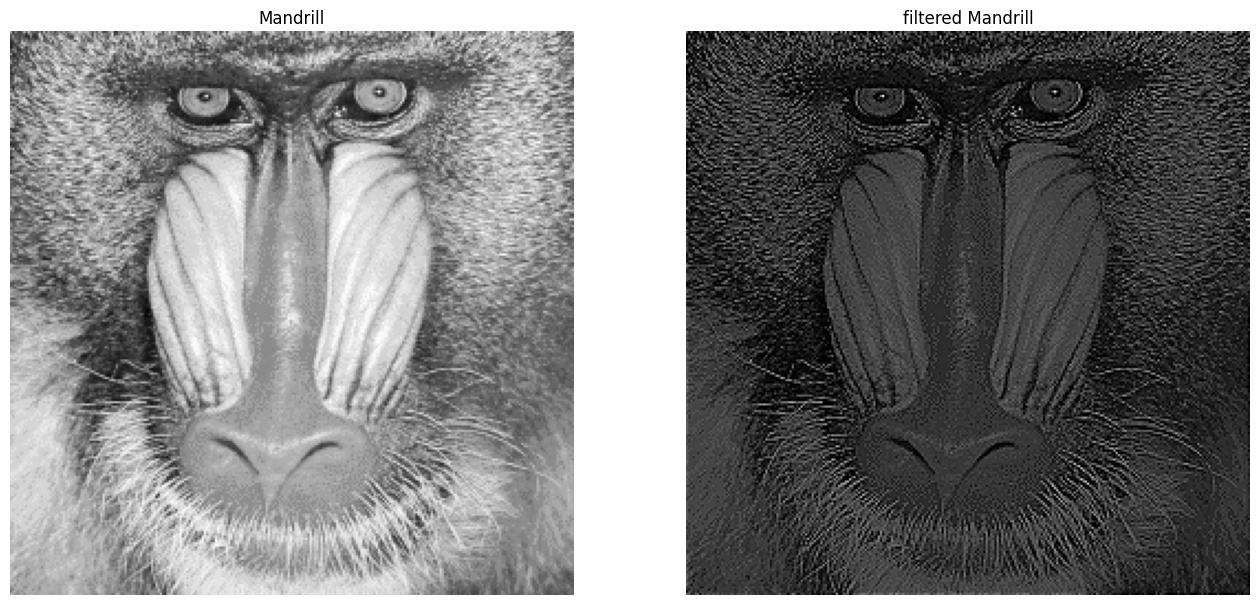

In [3]:
def apply_filter(image, kernel):
    n = int((kernel.shape[0]-1)/2)

    pad_image = np.pad(image, n, mode='wrap')
    filtered_image = np.zeros(image.shape, dtype='float')
    
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            filtered_image[x,y] = np.sum(pad_image[x:x+2*n+1,y:y+2*n+1]*kernel)

    filtered_image = np.clip(filtered_image, 0,255)
        
    return filtered_image

def convolve2d(image, kernel):
    """
    Effectue une convolution 2D entre une image et un kernel donné.

    Arguments :
    image :  L'image d'entrée.
    kernel : Le kernel du filtre.

    Retourne :
    numpy.n
        L'image filtrée après la convolution.
    """

    # Flip du kernel pour la convolution
    kernel = np.flipud(np.fliplr(kernel))

    output = apply_filter(image, kernel)

    return output

kernel = np.array([[0, -1, 0],
                [-1, 5, -1],
                [0, -1, 0]]) / 5

mandrill = io.imread("mandrill256.pgm")
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
plt.imshow(mandrill, cmap = 'gray')
plt.title('Mandrill')
plt.axis('off') 

filtered_mandrill = convolve2d(mandrill, kernel)
plt.subplot(1,2,2)
plt.imshow(filtered_mandrill, cmap = 'gray')
plt.title('filtered Mandrill')
plt.axis('off') 
plt.show()

**Question 1:** Quelle est l'importance de supprimer les variations lentes dues au signal utile avant d'estimer le bruit ?

Le bruit est dans les hautes fréquences. Pour estimer son écart type avec précision, on peut donc appliquer un filtre passe haut. Cela ne changera rien au bruit, mais diminuera l'influence des basses fréquences dans nos calculs. 

En effet, lorsque l'on calcule l'écart type d'un bloc, il est influencé par les contours lorsqu'il y en a, le bruit, et les dégradés (= variations lentes). Lorsque l'on applique un filtre passe haut, on supprime les dégradés de couleurs. Cela permet de calculer le vrai écart type du bruit lorsqu'il n'y a pas de contours.

**Question 2:** Interpréter le choix des éléments du kernel.



Le kernel est bien un filtre passe haut. En effet le coefficient central est élevé, et les coefficients voisins sont négatif. Cela signifie que ce filtre amplifie les variations locales, c'est à dire les hautes fréquences. C'est donc un passe haut.

La somme de ses valeurs est bien de 1, cela signifie qu'il est normalisé et n'amplifie pas les valeurs des pixels de l'image. C'est ce qui est souhaité.

**Exercise 2:** L'algorithme se résume par
pour tous les pixels de l’image filtrée
* calcul de l’écart type local du bloc de taille (2t + 1) × (2t +1) centré sur le pixel;
* Mise à jour de l’histogramme des écarts-types locaux;

In [4]:
def calcul_local_std_hist(filtered_image, t):
    # Initialiser l'histogramme des écarts-types locaux
    # Suppose que l'écart type varie de 0 à 255
    local_std_hist = []
    # Boucle pour tous les pixels de l'image filtrée
    for i in range(t, filtered_image.shape[0] - t):
        for j in range(t, filtered_image.shape[1] - t):
            # Extraire le bloc de pixels centré sur le pixel actuel
            block = filtered_image[i-t:i+t+1,j-t:j+t+1]
    
            # Calcul de l'écart type local
            std = np.std(block)
    
            # Mise à jour de l'histogramme des écarts-types locaux
            local_std_hist.append(std)
    return local_std_hist

**Exercise 3**: Calcul de l'histogramme cumulé.

**Exercise 4**: La dernière étape afin de calculer l'écart type final consiste à multiplier 1.13 × carttype qui atteint p% de l’histogramme cumulé. L’écart type calculé est naturellement un peu inférieur à l’écart type réel. Le facteur 1.13 est un facteur
multiplicatif destiné à corriger cette sous estimation. Il est obtenu de manière empirique.

**Exercise 5**: Charger l'image du mandrill, lui applique la méthode d'estimation du bruit, et afficher l' histogrammes de l' images filtrée et des écarts-types locaux correspondants.




**Remarque:**
La taille des
blocs et la valeur de pourcentile dépendent de l’écart type réel du bruit et du filtre passe-haut utilisé.
Pour des écarts types inférieurs à 60, une taille de bloc de t = 10 et une valeur de p = 0.5 sont de
bons paramètres. Au delà de 60, une taille de bloc de t = 15 et une valeur de p = 50 sont de meilleurs
paramètres.
Comme l’écart type réel est inconnu, on peut estimer une première fois le bruit avec un jeu de
paramètres standard t = 10, p = 0.5, puis avec le jeu le plus approprié selon cette première estimation si
besoin.

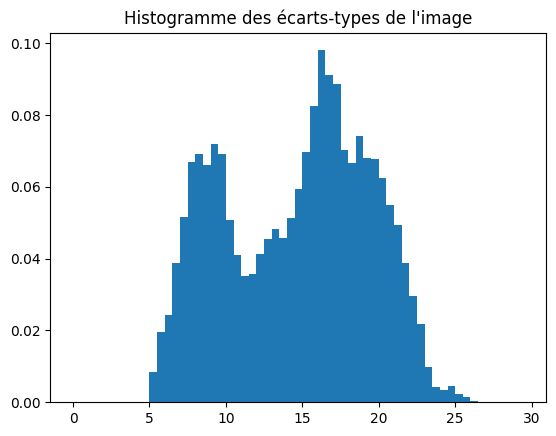

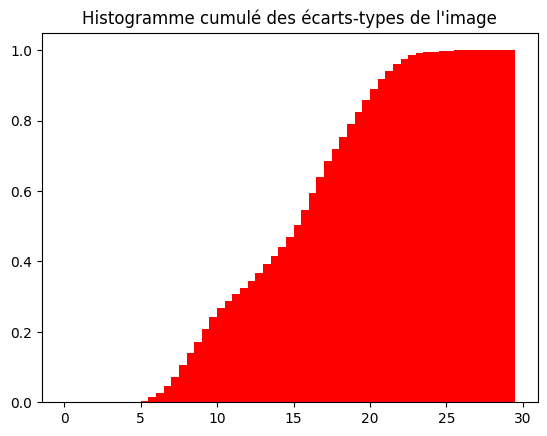

Ecart-type qui atteint 0.5% de l'histogramme cumulé :  5.532522483246716
Ecart-type final :  6.251750406068788


In [5]:
local_std_hist = calcul_local_std_hist(filtered_mandrill, 10)

plt.hist(local_std_hist, bins = [x*0.5 for x in range(60)], density=True)
plt.title("Histogramme des écarts-types de l'image")
plt.show()

plt.hist(local_std_hist, bins = [x*0.5 for x in range(60)], density=True, cumulative = True, color = 'r')
plt.title("Histogramme cumulé des écarts-types de l'image")
plt.show()

percentile = np.percentile(local_std_hist, 0.5)
print("Ecart-type qui atteint 0.5% de l'histogramme cumulé : ",percentile)
ec_final = percentile * 1.13
print("Ecart-type final : ", ec_final)

**Question 3:** Que pouvez-vous dire sur la forme de l'histogramme des écarts-types locaux ?



L'histogramme des écarts-types locaux semble indiquer qu'il n'y a presque aucune valeur en dessous de 5. Cela nous donne donc déjà une borne inférieure pour l'écart type du bruit. 

On remarque aussi que les écarts-types ne sont pas uniformément distribués. Il semble que la valeur 10 et 18 sont plus probables que les autres. Cela peut correspondre aux différents types de contours : par exemple les zones de poils, et les zones de  autour desquelles se concentrent la plupart des écarts types. Cela est probablement les deux contours : les zones de poils et les autres contours.

On observe que les écarts-types sont très largement inférieurs à $60$ pour une fenêtre de taille $t=10$. Cela suggère qu'il n'y a pas besoin de changer la valeur de $t$. On peut donc estimer la valeur de l'écart-type avec $p=0.5$. 

En réalisant cette estimation on trouve que $\sigma_{estimé} = 6.25$

# Filtre médian

Il consiste à remplacer le pixel central par la valeur médiane du voisinage (taille impaire) dans lequel
il se trouve. Ce filtre ne tient pas compte de la hauteur du bruit, au contraire des filtres linéaires,
puisqu’il opère un classement relatif. Dans l’image suivante

\begin{pmatrix}
40 & 50 & 60 \\
50 & 82 & 75 \\
80 & 90 & 95 \\
\end{pmatrix}

, le pixel central de valeur 82

est remplacé par la valeur 75 par un filtrage médian de taille 3 × 3.
Tout point hors de la norme est donc rejeté, quelque soit sa valeur. Il n’introduit donc pas de nouvelles
valeurs d’intensité et réduit la variance des intensités. Il permet d’éliminer les valeurs incorrectes isolées.
Il permet d’éliminer les oscillations d’intensité de période inférieure à la taille de la fenêtre ainsi que les
bruits impulsionnel.
La fenêtre utilisée pour le filtrage peut être une fenêtre carrée n × n, une croix n × n, une ligne ou
une colonne. Les effets de ce filtre varient significativement en fonction de cette fenêtre. Pour des grandes
tailles, le filtre utilisant une fenêtre carrée a tendance à éliminer (en les arrondissant) les angles et les
coins des contours, car toute impulsion inférieure à la taille du filtre est éliminée, quelque soit sa direction
(un angle est une impulsion dans une direction donnée).


Le temps d’exécution de ce filtre peut etre long car il impose un tri sur (2n + 1).(2n + 1) valeurs, et
augmente rapidement avec la taille du voisinage. Une manière élégante de réduire les temps d’exécution
d’un médian de grande taille consiste à utiliser l’histogramme cumulé qui s’obtient facilement entre 2
positions voisines de la fenêtre de traitement. L’algorithme sera implémenté dans l'exercise 7.


**Question 4:** Selon votre compréhension, lister deux avantages et deux inconvénients du filtre médian.

D'après ma compréhension, l'avantage principal du filtre médian est qu'il peu sensible aux valeurs extrêmes. Cela en fait donc un filtre très efficace contre les bruits impulsionnels de type sel et poivre. 

Le deuxième avantage est que contrairement aux filtres linéaires, il ne se laisse pas influencer par ces anomalies et préserve donc mieux les contours.

Parmi les inconvénients je note le temps de calcul. Il est nécessaire de calculer la médiane de chaque fenêtre, ce qui peut etre long. Il n'est pas possible de passer par la FFT comme on le faisait avec les filtres linéaires.

Il est dit aussi que pour des grandes fenêtres, le filtre a tendance à lisser les contours. Cela va donc poser problème pour les petits détails.


**Exercise 6:** En premier lieu, on vous demande d'écrire une fonction simple median_filter qui prend en arguments l'image et la taille de la fenêtre, pensez à utiliser np.pad pour bien ajouter des pixels aux bords de l'image. La fonction pad prend plusieurs arguments, dont l'image d'entrée, la taille du padding à ajouter à chaque bord, le mode de padding (dans ce cas, 'constant' pour remplir avec une valeur constante), et la valeur constante utilisée pour remplir les pixels ajoutés (dans ce cas, 0). Le paramètre padding_size est généralement défini comme la moitié de kernel_size.

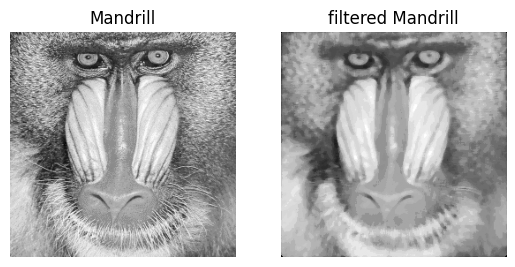

In [6]:
def median_filter(image, t):
    pad_image = np.pad(image,pad_width = t, mode = 'constant')
    filtered_image = np.zeros(image.shape)

    for i in range(0, image.shape[0]):
        for j in range(0, image.shape[1]):
            block = pad_image[i:i+2*t+1 , j:j+2*t+1]
            filtered_image[i,j] = np.median(block)

    return filtered_image



plt.subplot(1,2,1)
plt.imshow(mandrill, cmap = 'gray')
plt.title('Mandrill')
plt.axis('off') 

filtered_median_mandrill = median_filter(mandrill, 2)
plt.subplot(1,2,2)
plt.imshow(filtered_median_mandrill, cmap = 'gray')
plt.title('filtered Mandrill')
plt.axis('off') 
plt.show()

**Question 5:** Proposer une solution alternative au padding.

on pourrait juste ne pas prendre de pixels supplémentaires et uniquement les pixels du block à l'intérieur de l'image

**Exercise 7:** Maintenant, on s'intéresse à définir la fonction median_filter_with_cumulative_histogram ui prend en arguments l'image, sa taille N et la taille de la fenêtre, l'agorithme est défini ci-dessous.
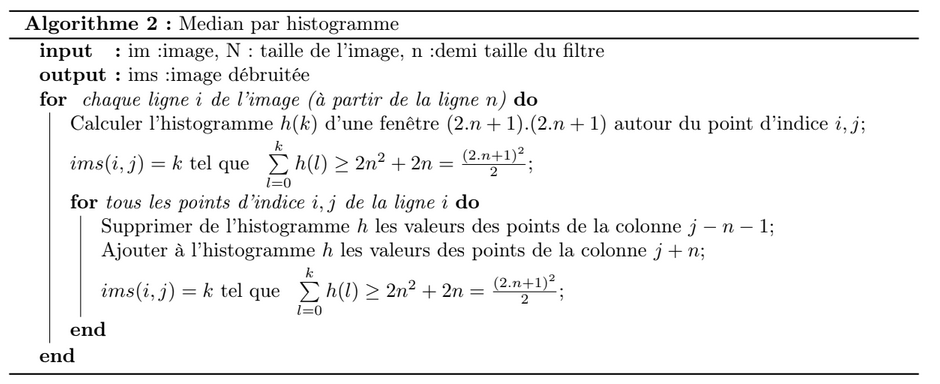

In [7]:
def median_filter_hist(image, n):

    filtered_image = np.zeros(image.shape)

    pad_image = np.pad(image, pad_width=n, mode = 'constant')
    
    for i in range(image.shape[0]):
        hist = np.bincount(pad_image[i:i+2*n+1, 0:2*n+1].flatten(), minlength = 256)
        filtered_image[i,0] = np.searchsorted(np.cumsum(hist), np.array([2*n**2+2*n]))[0]

        for j in range(1, image.shape[1]):
            np.add.at(hist, pad_image[i:i+2*n+1, j+2*n], 1)
            np.add.at(hist, pad_image[i:i+2*n+1, j-1], -1)
            filtered_image[i,j] = np.searchsorted(np.cumsum(hist), np.array([2*n**2+2*n]))[0]

    return filtered_image    

**Exercise 8:** a) Appliquer les fonctions des deux exercises précédents à l'image du mandrill, puis afficher les résultats.
Comparer le temps d'éxecution.

b)Question BONUS Changer la taille de la  fenêtre pour une image de votre choix (soit 10x10), interpréter les résultats.



Temps d'exécution filtre médian classique: 
5.0479059219997
Temps d'exécution filtre médian par histogramme cumulé: 
0.8717872719998923


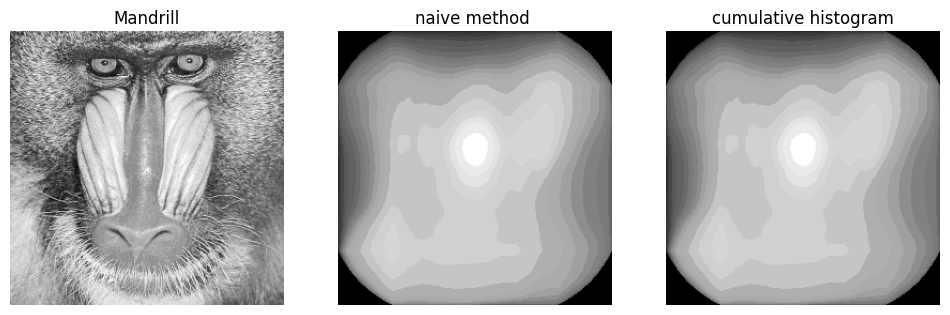

In [8]:
import time

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mandrill, cmap = 'gray')
plt.title('Mandrill')
plt.axis('off') 

start_time = time.perf_counter()

filtered_median_mandrill = median_filter(mandrill, 50)
end_time = time.perf_counter()
execution_time = end_time - start_time
print("Temps d'exécution filtre médian classique: ")
print(execution_time)
plt.subplot(1,3,2)
plt.imshow(filtered_median_mandrill, cmap = 'gray')
plt.title('naive method ')
plt.axis('off') 

start_time = time.perf_counter()
filtered_median_mandrill_hist = median_filter_hist(mandrill, 50)
end_time = time.perf_counter()
execution_time = end_time - start_time
print("Temps d'exécution filtre médian par histogramme cumulé: ")
print(execution_time)

plt.subplot(1,3,3)
plt.imshow(filtered_median_mandrill_hist, cmap = 'gray')
plt.title('cumulative histogram')
plt.axis('off') 
plt.show()

On remarque que le temps d'exécution est bien inférieur pour le filtre médian avec histogramme cumulé que par le calcul direct de la médiane. 

Logiquement, la différence est plus marquée lorsque la taille du filtre est élevée. Lorsque n = 50, on a un rapport de x6.

# Débruitage par patchs (Non-local Means)

Les filtres adaptifs en général sont des opérateurs de lissage qui modifient leur comportement ou leurs coefficients en
fonction du contexte local. Ils comportent généralement des seuils qui leur permettent de s’adapter aux
valeurs de bruits à éliminer. Leur inconvénient est la connaissance requise à priori du type de bruit et
des valeurs du bruit.


Consulter ce [site](https://fr.wikipedia.org/wiki/D%C3%A9bruitage_par_patchs) pour plus d'info.

L’idée du filtre Nlmeans est d’utiliser la redondance présente dans la plupart des images, cette redondance n’étant pas spécifiquement locale. De ce fait, il est possible de faire le lissage (moyenne pondérée) de pixels qui ne sont pas voisins. Le patch est un voisinage de petite taille autour d’un pixel. La région est
un voisinage de plus grande taille autour de ce pixel. Le principe de cette méthode, pour traiter un pixel,
est donc de rechercher d’autres pixels dans la région qui ont le même environnement ou patch. Le lissage consiste à réaliser la moyenne pondérée de ces pixels dont les patchs se ressemblent, la pondération étant
proportionnelle à la dissemblance entre 2 patchs. L’algorithme s’écrit:


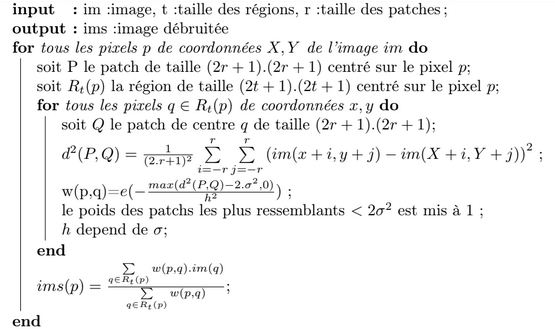

In [37]:
def Nl_Means(image, t, r, sigma, h):
    
    ims = np.zeros(image.shape)
    pad_image = np.pad(image, pad_width=r+t, mode = 'reflect')
    
    for X in range(image.shape[0]):
        print(f"Progression: {X}/{image.shape[0]}", end='\r')
        for Y in range(image.shape[1]):
            P = pad_image[t+X:t+X+2*r+1 , t+Y:t+Y+2*r+1]
            R_t = pad_image[r+X:r+X+2*t+1 , r+Y:r+Y+2*t+1]

            w = np.zeros((2*t+1,2*t+1))

            for x in range(r+X, r+X+2*t+1):
                for y in range(r+Y, r+Y+2*t+1):

                    somme = np.sum((pad_image[x-r:x+r+1 , y-r:y+r+1] - P)**2)
                    d2_pq = somme / (2*r+1)**2

                    w[x-X-r][y-Y-r] = np.exp(-max(d2_pq - 2*sigma**2, 0)/h**2)

            ims[X,Y] = np.sum(w * R_t)/np.sum(w)

    return ims

**Exercise 10**:  Ecrirue une fonction qui utilise une boucle pour itérer sur chaque valeur du tableau et appliquer l'algorithme NI-Means à chacune d'entre elles.

| Sigma  | Patch | Région | h |
|-------------|----------|-------|--------------------|
| <=15        | 3        | 21    | 0.40σ              |
| <=30        | 5        | 21    | 0.40σ              |
| <=45        | 7        | 35    | 0.35σ              |
| <=75        | 9        | 35    | 0.35σ              |
| <=100       | 11       | 35    | 0.30σ              |


In [95]:
def parcours_bruit_nl_means(image):

    plt.figure(figsize = (12,8))

    plt.subplot(2,3,1)
    plt.imshow(image, cmap = 'gray')
    plt.title("Initial Mandrill")
    plt.axis("off")

    sigma  = 10
    t = 10
    p = 2
    h = 0.40*sigma
    nl_means_image = Nl_Means(image, t, p, sigma, h)

    
    plt.subplot(2,3,2)
    plt.imshow(nl_means_image, cmap = 'gray')
    plt.title(f'sigma = {sigma}, p = {p}, R = {t}, h = {round(h,1)}')
    plt.axis('off') 

    sigma  = 25
    t = 10
    p = 3
    h = 0.40*sigma
    nl_means_image2 = Nl_Means(image, t, p, sigma, h)
    plt.subplot(2,3,3)
    plt.imshow(nl_means_image2, cmap = 'gray')
    plt.title(f'sigma = {sigma}, p = {p}, R = {t}, h = {round(h,1)}')
    plt.axis('off') 

    sigma  = 40
    t = 17
    p = 4
    h = 0.35*sigma
    nl_means_image = Nl_Means(image, t, p, sigma, h)
    plt.subplot(2,3,4)
    plt.imshow(nl_means_image, cmap = 'gray')
    plt.title(f'sigma = {sigma}, p = {p}, R = {t}, h = {round(h,1)}')
    plt.axis('off') 

    sigma  = 75
    t = 17
    p = 5
    h = 0.35*sigma
    nl_means_image = Nl_Means(image, t, p, sigma, h)
    plt.subplot(2,3,5)
    plt.imshow(nl_means_image, cmap = 'gray')
    plt.title(f'sigma = {sigma}, p = {p}, R = {t}, h = {round(h,1)}')
    plt.axis('off') 

    sigma  = 90
    t = 17
    p = 6
    h = 0.35*sigma
    nl_means_image = Nl_Means(image, t, p, sigma, h)
    plt.subplot(2,3,6)
    plt.imshow(nl_means_image, cmap = 'gray')
    plt.title(f'sigma = {sigma}, p = {p}, R = {t}, h = {round(h,1)}')
    plt.axis('off')
    plt.show()


**Exercise 11:**
Appliquer la fonction de l'exercise précédent à l'image du mandrill, afficher les résultats et comparer qualitativement l'effet de plusieurs paramètres sur le débruitage.

In [96]:
#parcours_bruit_nl_means(mandrill)
#trop long 

J'ai eu des difficultés à réaliser cette question car il m'était impossible d'exécuter cet algorithme sur ma machine en temps raisonable. Cela me prenait environ 30min par image. J'ai donc décidé de diminuer la résolution de mon image mandrill. C'est le seul moyen de pouvoir l'exécuter en temps raisonnable.

Pour réaliser cette réduction de dimension, j'ai utilisé une technique vue en CM. J'ai effectué une TFD (grâce à la FFT), puis j'ai rogné les hautes fréquences. Ensuite, lorsque je prends la iFFT j'ai donc une image de taille plus petite, en ayant perdu le minimum de détails. 

initial shape :  (256, 256)
half shape : (128, 128)
quarter shape :  (64, 64)


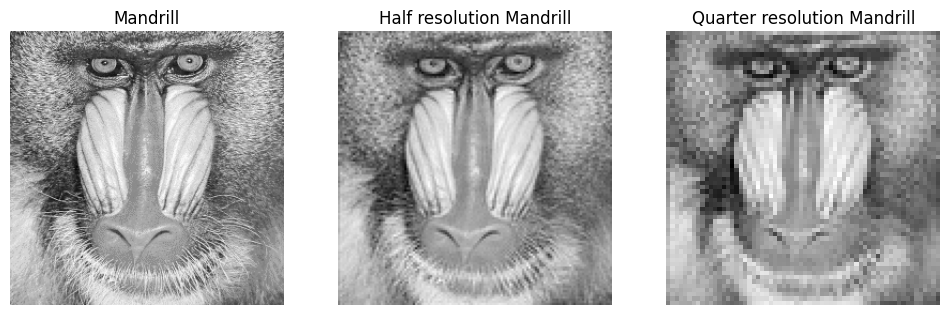

In [97]:
def downsize_image(image):
    N = image.shape[0]
    M = image.shape[1]
    fft_image = np.fft.fftshift(np.fft.fft2(image))
    downsize_image_fft = fft_image[round(N*0.25):round(N*0.75) , round(M*0.25):round(M*0.75)]
    downsize_image = np.real(np.fft.ifft2(np.fft.ifftshift(downsize_image_fft)))
    return downsize_image

plt.figure(figsize = (12,4))
print("initial shape : ", mandrill.shape)
plt.subplot(1,3,1)
plt.imshow(mandrill, cmap = 'gray')
plt.title('Mandrill')
plt.axis('off') 

downsize_mandrill = downsize_image(mandrill)
print("half shape :", downsize_mandrill.shape)
plt.subplot(1,3,2)
plt.imshow(downsize_mandrill, cmap = 'gray')
plt.title('Half resolution Mandrill')
plt.axis('off') 

quarter_downsize_mandrill = downsize_image(downsize_mandrill)
print("quarter shape : ", quarter_downsize_mandrill.shape)
plt.subplot(1,3,3)
plt.imshow(quarter_downsize_mandrill, cmap = 'gray')
plt.title('Quarter resolution Mandrill')
plt.axis('off') 
plt.show()
    

On remarque une perte de détail visible, c'est normal car on a divisé par 4 la résolution de l'image. Cela a probablement une influence sur l'algorithme étant donné que les régions représentent une taille plus importante par rapport à l'image. Il faudrait donc ajuster les paramètres de l'algorithme pour être dans les mêmes conditions qu'initialement. J'ai donc réduit les paramètres de Région et de Patch pour correspondre à mes ajustements.

Toutefois c'est la seule manière pour moi d'exécuter cette cellule, donc je vais faire avec, et en tenir compte dans mes analyses. J'ai choisi de diviser la résolution par 2, ce qui me permet de diviser mon temps de calcul par 4. C'est un bon compromis entre temps de calcul et précision. Diviser par 4 la résolution semble dénaturer trop l'image.

Progression: 127/128

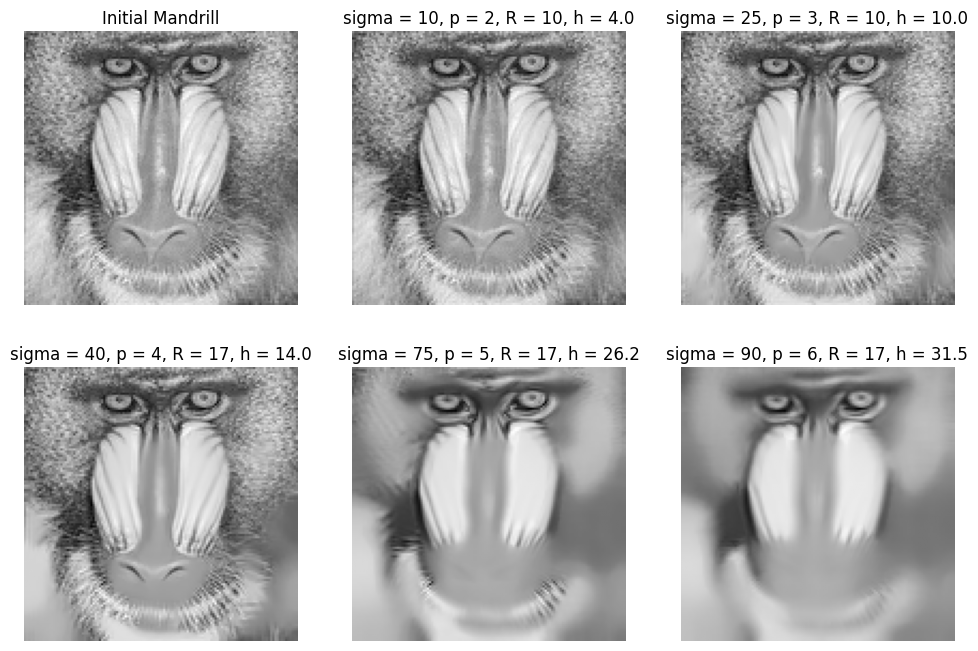

In [98]:
parcours_bruit_nl_means(downsize_mandrill)

On remarque que lorsque les patchs sont petits, on conserve les détails fins mais on est surement moins robuste au bruit. 

Lorsque la région est grande, on augmente les chances de trouver des patches très similaires. En effet, on observe que la réduction du bruit est meilleure. Cependant, le temps de calcul est nettement plus long. 

Le paramètre h joue sur la tolérance à la différence entre patches. Lorsque h est très élevé, le filtre est plus tolérant aux différences entre patches, ce qui permet de conserver plus de détails, mais aussi plus de bruit. 

Plus sigma est élevé, plus le bruit est important. Il faut donc ajuster les paramètrs r,t et h pour élargir la recherche (patches et régions plus grands) et affiner la pondération (h plus petit).